# PPA Exposure Modelling — Step 4  
## Monthly calibration of the Schwartz one-factor model for DK1

This notebook calibrates the historical dynamics used by the Monte Carlo engine in Step 5.

**Final modelling choice used in the prototype:** monthly calibration of a shifted-log Schwartz one-factor model.

$$
X_t = \ln(S_t + c)
$$

$$
X_t = \theta + f(t) + Y_t
$$

$$
dY_t = -\kappa Y_t\,dt + \sigma\,dW_t
$$

where:

- \(S_t\) is the DK1 monthly baseload spot price in EUR/MWh.
- \(c\) is a positive shift to handle possible negative power prices.
- \(f(t)\) is a deterministic annual and semi-annual seasonal component.
- \(Y_t\) is a mean-reverting residual factor.
- \(\kappa\) controls the speed of mean reversion.
- \(\sigma\) controls the volatility of the residual factor.

### Why this version replaces the previous daily calibration

The previous version calibrated the model on **daily** DK1 spot prices. That captured short-term electricity spot dynamics, but it produced a very fast mean-reversion speed. When used inside a **monthly-settled 5-year PPA exposure model**, the conditional state decayed almost immediately, leading to near-deterministic MtM profiles.

For this case, the calibration frequency should match the exposure modelling frequency. The PPA settles monthly, so this notebook calibrates the same model on **monthly aggregated DK1 prices**. This keeps the model simple and transparent, while making \(\kappa\) reflect multi-month price dynamics rather than intra-week noise.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("../data")

# -------------------------------------------------------------------------
# BEFORE / OLD VERSION:
# The first version used daily spot prices and DT_YEARS = 1 / 365.25.
# That produced a very fast mean-reversion speed suitable for daily spot noise,
# but too fast for a monthly-settled PPA exposure model.
#
# SPOT_DAILY_PATH = DATA_DIR / "spot_dk1_2021-01-01_2026-06-04_daily.csv"
# DT_YEARS = 1.0 / 365.25
# -------------------------------------------------------------------------

# NOW / FINAL VERSION:
# Use monthly DK1 spot prices and monthly time step.
SPOT_MONTHLY_PATH = DATA_DIR / "spot_dk1_2021-01-01_2026-06-04_monthly.csv"
OUTPUT_PARAMS = DATA_DIR / "model_params_dk1_20260604.json"

DT_YEARS = 1.0 / 12.0

# Shift used in X_t = log(S_t + c).
# Power prices can be negative, so a shift makes the log transformation well-defined.
# The chosen value must be large enough to keep S_t + c positive in the calibration window.
SHIFT_CONSTANT = 100.0

# Basic sanity thresholds used only for diagnostics.
MIN_OBS = 36

## 1. Load and inspect monthly DK1 spot data

We use the monthly spot file generated in Step 1. The final partial month is excluded because it is not a full monthly average and would bias the calibration.

In [2]:
spot = (
    pd.read_csv(SPOT_MONTHLY_PATH, parse_dates=["YearMonth"])
    .rename(columns={"YearMonth": "Date"})
    .sort_values("Date")
    .reset_index(drop=True)
)

required_cols = {"Date", "SpotPriceEUR", "DaysInMonth"}
missing = required_cols.difference(spot.columns)
if missing:
    raise ValueError(f"Missing columns in monthly spot file: {missing}")

# Drop incomplete months. In the current file, June 2026 only has 4 days.
spot["CalendarDays"] = spot["Date"].dt.days_in_month
spot["IsFullMonth"] = spot["DaysInMonth"] == spot["CalendarDays"]

excluded_partial = spot.loc[~spot["IsFullMonth"], ["Date", "SpotPriceEUR", "DaysInMonth", "CalendarDays"]]
spot = spot.loc[spot["IsFullMonth"], ["Date", "SpotPriceEUR", "DaysInMonth"]].dropna().reset_index(drop=True)

if len(spot) < MIN_OBS:
    raise ValueError(f"Too few monthly observations for calibration: {len(spot)}")

print(f"Monthly DK1 observations used: {len(spot):,}")
print(f"Calibration window: {spot['Date'].min().date()} -> {spot['Date'].max().date()}")

if not excluded_partial.empty:
    print("\nExcluded partial months:")
    print(excluded_partial.to_string(index=False))

print("\nMonthly spot price summary, EUR/MWh:")
print(spot["SpotPriceEUR"].describe().round(2))

spot.tail()

Monthly DK1 observations used: 65
Calibration window: 2021-01-01 -> 2026-05-01

Excluded partial months:
      Date  SpotPriceEUR  DaysInMonth  CalendarDays
2026-06-01    110.243802            4            30

Monthly spot price summary, EUR/MWh:
count     65.00
mean     108.05
std       71.70
min       45.08
25%       71.71
50%       84.74
75%      113.12
max      456.75
Name: SpotPriceEUR, dtype: float64


,Date,SpotPriceEUR,DaysInMonth
60,2026-01-01,105.579775,31
61,2026-02-01,96.108728,28
62,2026-03-01,97.472974,31
63,2026-04-01,83.163986,30
64,2026-05-01,99.974452,31


## 2. Apply shifted-log transformation

The model is calibrated on:

$$
X_t = \ln(S_t + c)
$$

The shift \(c\) is used because electricity prices can be negative. This avoids excluding negative-price observations and keeps the model numerically stable.

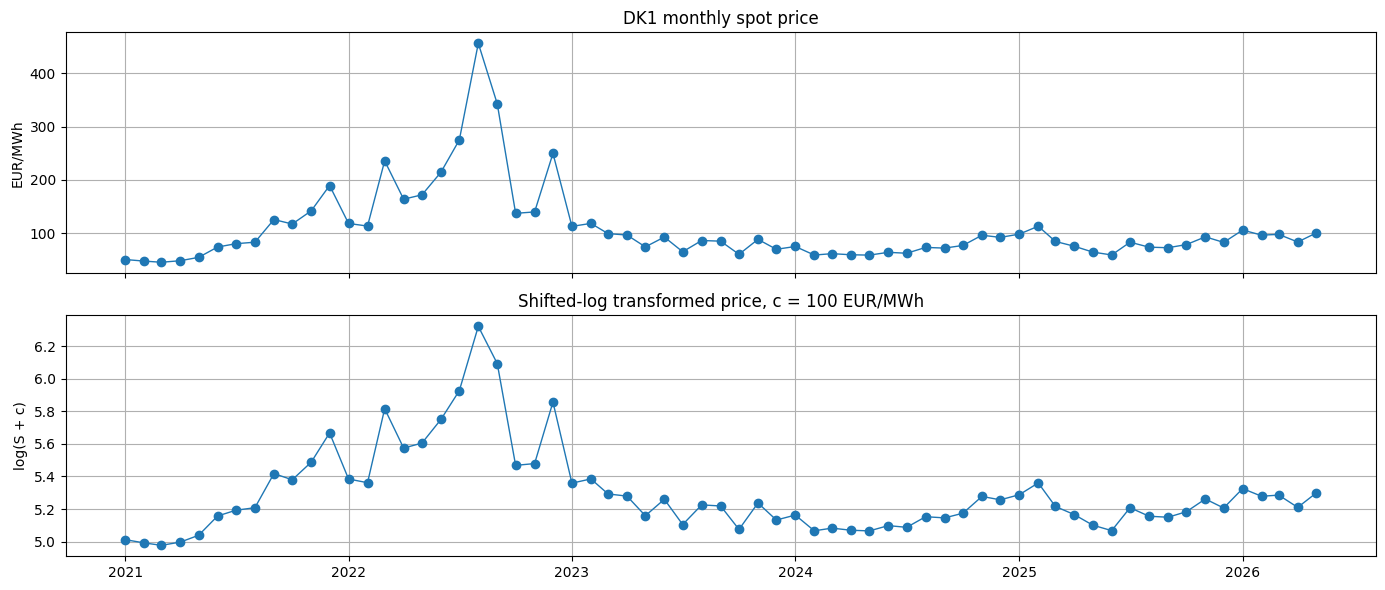

In [3]:
min_price = spot["SpotPriceEUR"].min()
if min_price + SHIFT_CONSTANT <= 0:
    raise ValueError(
        f"SHIFT_CONSTANT={SHIFT_CONSTANT} is insufficient: min price is {min_price:.2f}. "
        "Increase the shift so that S_t + c > 0 for all observations."
    )

spot["X"] = np.log(spot["SpotPriceEUR"] + SHIFT_CONSTANT)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(spot["Date"], spot["SpotPriceEUR"], marker="o", linewidth=1.0)
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title("DK1 monthly spot price")

axes[1].plot(spot["Date"], spot["X"], marker="o", linewidth=1.0)
axes[1].set_ylabel("log(S + c)")
axes[1].set_title(f"Shifted-log transformed price, c = {SHIFT_CONSTANT:.0f} EUR/MWh")

plt.tight_layout()
plt.show()

## 3. Fit deterministic seasonality by OLS

We fit an annual and semi-annual deterministic seasonal component:

$$
X_t = \theta
+ A_1 \cos(\omega t) + B_1 \sin(\omega t)
+ A_2 \cos(2\omega t) + B_2 \sin(2\omega t)
+ \eta_t
$$

For monthly data:

$$
\omega = \frac{2\pi}{12}
$$



The residual $\eta_t$ is then used to calibrate the OU residual factor.

In [4]:
spot["t_months"] = np.arange(len(spot), dtype=float)
omega = 2 * np.pi / 12.0

t = spot["t_months"].values
X_design = np.column_stack([
    np.ones(len(spot)),
    np.cos(omega * t),
    np.sin(omega * t),
    np.cos(2 * omega * t),
    np.sin(2 * omega * t),
])

y = spot["X"].values
beta, residuals_sum, rank, singular_values = np.linalg.lstsq(X_design, y, rcond=None)

theta, A1, B1, A2, B2 = beta
spot["X_fit"] = X_design @ beta
spot["resid"] = spot["X"] - spot["X_fit"]

r2 = 1 - np.sum(spot["resid"] ** 2) / np.sum((spot["X"] - spot["X"].mean()) ** 2)
seasonal_amplitude_log = np.max(spot["X_fit"] - theta) - np.min(spot["X_fit"] - theta)

print("OLS seasonality parameters:")
print(f"  theta = {theta:.6f}")
print(f"  A1    = {A1:.6f}")
print(f"  B1    = {B1:.6f}")
print(f"  A2    = {A2:.6f}")
print(f"  B2    = {B2:.6f}")
print(f"\nSeasonality R²: {r2:.3f}")
print(f"Seasonal log-amplitude range: {seasonal_amplitude_log:.3f}")

spot[["Date", "SpotPriceEUR", "X", "X_fit", "resid"]].head()

OLS seasonality parameters:
  theta = 5.300882
  A1    = -0.011270
  B1    = -0.071693
  A2    = 0.019789
  B2    = 0.013026

Seasonality R²: 0.043
Seasonal log-amplitude range: 0.161


,Date,SpotPriceEUR,X,X_fit,resid
0,2021-01-01,50.205108,5.012002,5.309402,-0.297400
1,2021-02-01,47.261503,4.992210,5.276451,-0.284241
2,2021-03-01,45.077861,4.977271,5.234545,-0.257275
3,2021-04-01,47.967111,4.996990,5.209400,-0.212410
4,2021-05-01,54.307567,5.038948,5.223254,-0.184306


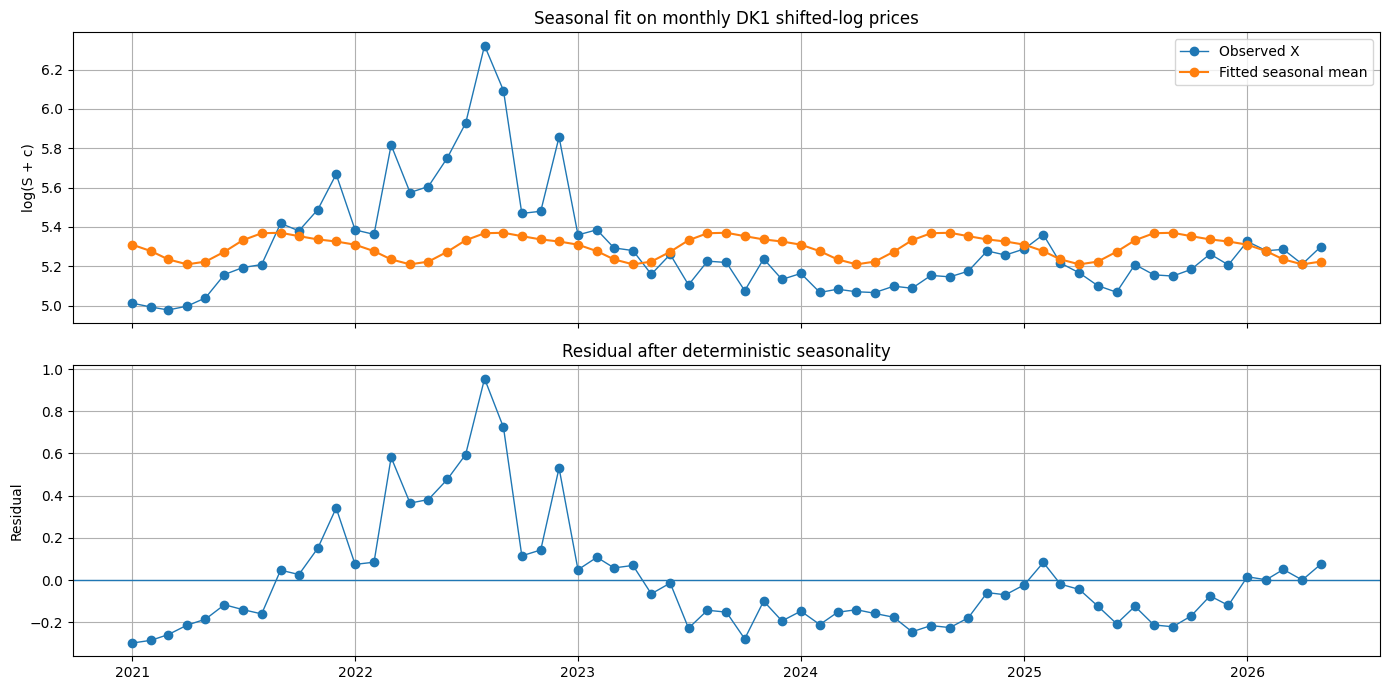

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(spot["Date"], spot["X"], marker="o", linewidth=1.0, label="Observed X")
axes[0].plot(spot["Date"], spot["X_fit"], marker="o", linewidth=1.5, label="Fitted seasonal mean")
axes[0].set_ylabel("log(S + c)")
axes[0].set_title("Seasonal fit on monthly DK1 shifted-log prices")
axes[0].legend()

axes[1].plot(spot["Date"], spot["resid"], marker="o", linewidth=1.0)
axes[1].axhline(0, linewidth=1.0)
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual after deterministic seasonality")

plt.tight_layout()
plt.show()

,month_number,seasonal_log_component,implied_seasonal_level_EUR_MWh
0,1,0.009,102.229
1,2,-0.024,95.674
2,3,-0.066,87.644
3,4,-0.091,82.984
4,5,-0.078,85.537
5,6,-0.027,95.080
6,7,0.031,106.839
7,8,0.067,114.362
8,9,0.069,114.861
9,10,0.052,111.196


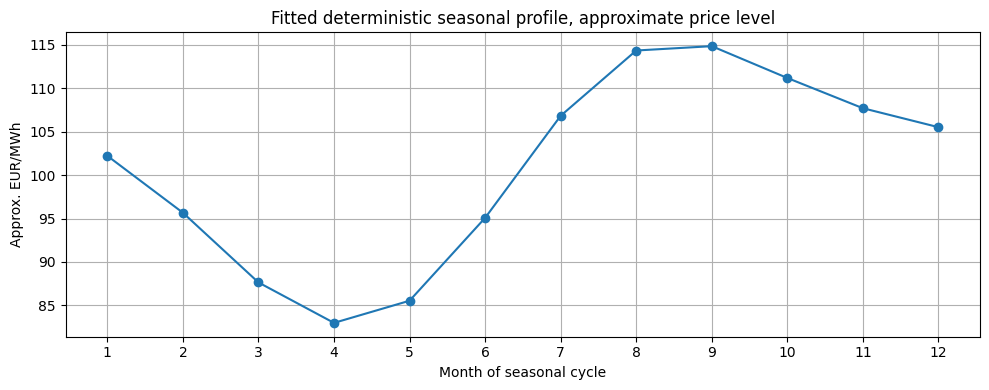

In [6]:
# Show the fitted seasonal component over one representative year.
month_grid = np.arange(12, dtype=float)
seasonal_log = (
    A1 * np.cos(omega * month_grid)
    + B1 * np.sin(omega * month_grid)
    + A2 * np.cos(2 * omega * month_grid)
    + B2 * np.sin(2 * omega * month_grid)
)
seasonal_level_approx = np.exp(theta + seasonal_log) - SHIFT_CONSTANT

seasonality_table = pd.DataFrame({
    "month_number": np.arange(1, 13),
    "seasonal_log_component": seasonal_log,
    "implied_seasonal_level_EUR_MWh": seasonal_level_approx,
})

display(seasonality_table.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(seasonality_table["month_number"], seasonality_table["implied_seasonal_level_EUR_MWh"], marker="o")
ax.set_xticks(np.arange(1, 13))
ax.set_xlabel("Month of seasonal cycle")
ax.set_ylabel("Approx. EUR/MWh")
ax.set_title("Fitted deterministic seasonal profile, approximate price level")
plt.tight_layout()
plt.show()

## 4. Calibrate OU residual dynamics via AR(1)

The exact monthly discretisation of a zero-mean OU process is:

$$
Y_{t+\Delta t} = \phi Y_t + \epsilon_t
$$

where:

$$
\phi = e^{-\kappa \Delta t}
$$

Therefore:

$$
\kappa = -\frac{\ln(\phi)}{\Delta t}
$$

and:

$$
\operatorname{Var}(\epsilon_t)
= \frac{\sigma^2}{2\kappa}(1-e^{-2\kappa\Delta t})
$$

which gives:

$$
\sigma
= \sqrt{\operatorname{Var}(\epsilon_t)\frac{2\kappa}{1-e^{-2\kappa\Delta t}}}
$$

Because the residuals from the seasonal regression are centred around zero, the primary calibration uses an AR(1) **without intercept**, consistent with the zero-mean OU factor used in Step 5.

In [7]:
resid = spot["resid"].values
x = resid[:-1]
y = resid[1:]

# Primary calibration: zero-intercept AR(1), consistent with zero-mean OU residual factor.
phi_hat = float(np.dot(x, y) / np.dot(x, x))
innov = y - phi_hat * x

if not (0 < phi_hat < 1):
    raise ValueError(
        f"Estimated AR(1) phi={phi_hat:.4f} is outside (0, 1). "
        "This would not imply a stationary mean-reverting OU."
    )

kappa = -np.log(phi_hat) / DT_YEARS
innov_var = np.var(innov, ddof=1)
sigma = np.sqrt(innov_var * 2 * kappa / (1 - np.exp(-2 * kappa * DT_YEARS)))

half_life_years = np.log(2) / kappa
half_life_months = half_life_years * 12
half_life_days = half_life_years * 365.25

# Secondary diagnostic only: AR(1) with intercept.
X_ar_intercept = np.column_stack([np.ones(len(x)), x])
a_hat_int, phi_hat_int = np.linalg.lstsq(X_ar_intercept, y, rcond=None)[0]
innov_int = y - (a_hat_int + phi_hat_int * x)
kappa_int = -np.log(phi_hat_int) / DT_YEARS if 0 < phi_hat_int < 1 else np.nan
half_life_months_int = np.log(2) / kappa_int * 12 if np.isfinite(kappa_int) else np.nan

print("Primary OU calibration, monthly residuals:")
print(f"  phi monthly        = {phi_hat:.4f}")
print(f"  kappa per year     = {kappa:.4f}")
print(f"  half-life          = {half_life_months:.2f} months  ({half_life_days:.1f} days)")
print(f"  sigma annualized   = {sigma:.4f}")
print(f"  innovation std     = {np.sqrt(innov_var):.4f} per monthly step")

print("\nIntercept AR(1) diagnostic, not used in Step 5:")
print(f"  intercept          = {a_hat_int:.6f}")
print(f"  phi monthly        = {phi_hat_int:.4f}")
print(f"  implied half-life  = {half_life_months_int:.2f} months")

Primary OU calibration, monthly residuals:
  phi monthly        = 0.7941
  kappa per year     = 2.7660
  half-life          = 3.01 months  (91.5 days)
  sigma annualized   = 0.5986
  innovation std     = 0.1547 per monthly step

Intercept AR(1) diagnostic, not used in Step 5:
  intercept          = 0.005577
  phi monthly        = 0.7942
  implied half-life  = 3.01 months


## 5. Residual diagnostics

These diagnostics are not meant to prove the model is perfect. They are included to make the prototype transparent and auditable.

The model is intentionally simple: it captures mean reversion and seasonality, while leaving jumps, regime switching, and multi-factor term-structure dynamics as documented extensions.

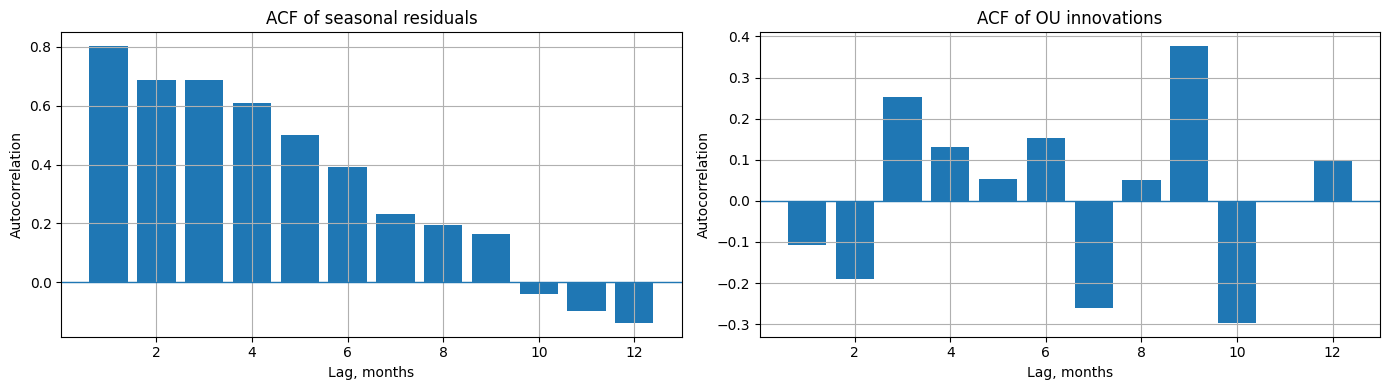

Residual ACF:


,lag,acf
0,1,0.802
1,2,0.687
2,3,0.688
3,4,0.609
4,5,0.499
5,6,0.393
6,7,0.232
7,8,0.196
8,9,0.163
9,10,-0.038



Innovation ACF:


,lag,acf
0,1,-0.108
1,2,-0.191
2,3,0.253
3,4,0.131
4,5,0.053
5,6,0.154
6,7,-0.260
7,8,0.051
8,9,0.376
9,10,-0.297


In [8]:
def acf_values(series: np.ndarray, max_lag: int = 12) -> pd.DataFrame:
    values = []
    s = np.asarray(series)
    for lag in range(1, max_lag + 1):
        if len(s) <= lag:
            break
        values.append({
            "lag": lag,
            "acf": np.corrcoef(s[:-lag], s[lag:])[0, 1],
        })
    return pd.DataFrame(values)

acf_resid = acf_values(resid, max_lag=12)
acf_innov = acf_values(innov, max_lag=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(acf_resid["lag"], acf_resid["acf"])
axes[0].axhline(0, linewidth=1)
axes[0].set_title("ACF of seasonal residuals")
axes[0].set_xlabel("Lag, months")
axes[0].set_ylabel("Autocorrelation")

axes[1].bar(acf_innov["lag"], acf_innov["acf"])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("ACF of OU innovations")
axes[1].set_xlabel("Lag, months")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

print("Residual ACF:")
display(acf_resid.round(3))
print("\nInnovation ACF:")
display(acf_innov.round(3))

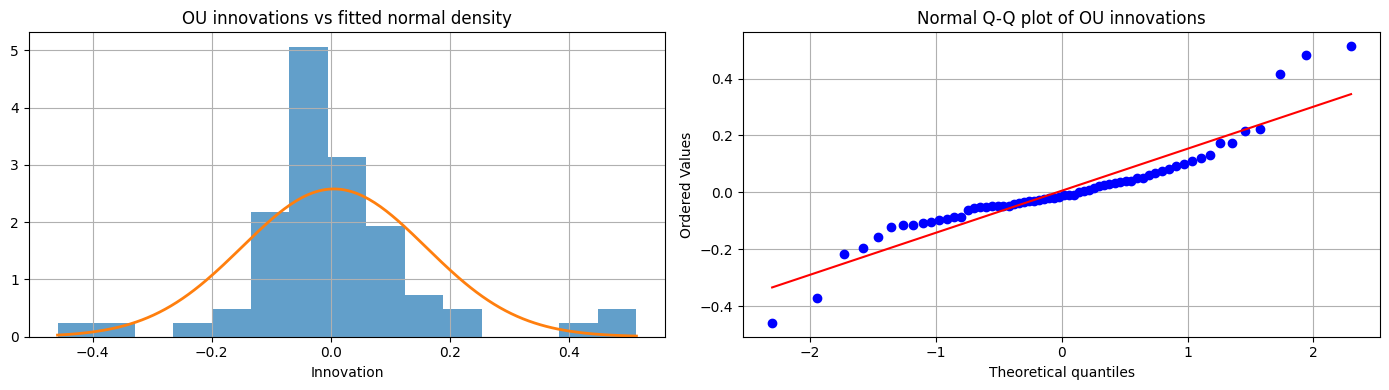

Innovation distribution diagnostics:
  mean      = 0.00558
  std       = 0.15467
  skew      = 0.669
  excess kurtosis = 3.387
  Jarque-Bera p-value = 0.0000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(innov, bins=15, density=True, alpha=0.7)
mu_i = np.mean(innov)
sd_i = np.std(innov, ddof=1)
x_grid = np.linspace(innov.min(), innov.max(), 200)
axes[0].plot(x_grid, stats.norm.pdf(x_grid, mu_i, sd_i), linewidth=2)
axes[0].set_title("OU innovations vs fitted normal density")
axes[0].set_xlabel("Innovation")

stats.probplot(innov, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot of OU innovations")

plt.tight_layout()
plt.show()

jb = stats.jarque_bera(innov)
print("Innovation distribution diagnostics:")
print(f"  mean      = {mu_i:.5f}")
print(f"  std       = {sd_i:.5f}")
print(f"  skew      = {stats.skew(innov):.3f}")
print(f"  excess kurtosis = {stats.kurtosis(innov):.3f}")
print(f"  Jarque-Bera p-value = {jb.pvalue:.4f}")

## 6. Compare against the previous daily-calibration issue

This cell is included for documentation. It explains why the monthly calibration is used in the final model.

If $\kappa$ is very high, the state dependence of the conditional expectation decays too quickly:

$$
e^{-\kappa \Delta t}
$$

For a monthly exposure model, this coefficient should not be almost zero after one month. A daily calibration can produce such a result because it captures short-lived intra-week spot price noise rather than the multi-month dynamics relevant for a monthly PPA.

In [10]:
# This is illustrative only. Replace this with the exact old daily kappa if you want to show the comparison.
# The previous run produced a very high kappa, roughly in the order of 150 per year.
old_daily_kappa_illustrative = 150.0

comparison = pd.DataFrame({
    "calibration": ["Old daily calibration, illustrative", "Final monthly calibration"],
    "kappa_per_year": [old_daily_kappa_illustrative, kappa],
})
comparison["decay_after_1_month"] = np.exp(-comparison["kappa_per_year"] * (1 / 12))
comparison["half_life_months"] = np.log(2) / comparison["kappa_per_year"] * 12

print("Effect of kappa on state persistence over one monthly step:")
display(comparison.round(6))

Effect of kappa on state persistence over one monthly step:


,calibration,kappa_per_year,decay_after_1_month,half_life_months
0,"Old daily calibration, illustrative",150.000000,0.000004,0.055452
1,Final monthly calibration,2.766004,0.794136,3.007142


## 7. Save calibrated parameters for Step 5

The Monte Carlo engine in Step 5 reads `model_params_dk1_20260604.json`. This notebook overwrites that file with the monthly-calibrated parameters.

In [11]:
params = {
    "model": "schwartz_one_factor_shifted_log_with_seasonality",
    "price_area": "DK1",
    "calibration_frequency": "monthly",
    "calibration_rationale": (
        "Monthly calibration is used because the PPA exposure engine works on monthly settlement dates. "
        "This aligns the mean-reversion speed with the relevant exposure horizon and avoids using daily spot noise "
        "to parameterise a five-year monthly exposure model."
    ),
    "calibration_date": str(spot["Date"].max().date()),
    "calibration_window": {
        "start": str(spot["Date"].min().date()),
        "end": str(spot["Date"].max().date()),
        "n_months": int(len(spot)),
    },
    "shift_constant_c": float(SHIFT_CONSTANT),
    "transform": "X_t = log(S_t + c)",
    "dt_years": float(DT_YEARS),
    "seasonality_specification": "theta + A1*cos(omega*t) + B1*sin(omega*t) + A2*cos(2*omega*t) + B2*sin(2*omega*t), with t in months",
    "parameters": {
        "kappa_per_year": float(kappa),
        "sigma_annualized": float(sigma),
        "theta": float(theta),
        "A1": float(A1),
        "B1": float(B1),
        "A2": float(A2),
        "B2": float(B2),
        "omega": float(omega),
        "phi_monthly": float(phi_hat),
    },
    "derived": {
        "half_life_years": float(half_life_years),
        "half_life_months": float(half_life_months),
        "half_life_days": float(half_life_days),
        "seasonality_r2": float(r2),
        "innovation_std_monthly": float(np.sqrt(innov_var)),
    },
    "diagnostics": {
        "ar1_with_intercept_intercept": float(a_hat_int),
        "ar1_with_intercept_phi": float(phi_hat_int),
        "innovation_mean": float(mu_i),
        "innovation_std": float(sd_i),
        "innovation_skew": float(stats.skew(innov)),
        "innovation_excess_kurtosis": float(stats.kurtosis(innov)),
        "jarque_bera_pvalue": float(jb.pvalue),
    },
    "model_limitations": [
        "Single-factor model: does not capture separate short-term and long-term risk factors.",
        "Gaussian residual innovations: does not explicitly model jumps or price spikes.",
        "Shifted-log specification prevents simulated prices below -c; negative prices are possible only down to the selected shift boundary.",
        "Monthly calibration is appropriate for monthly exposure but does not model hourly, daily, or intramonth collateral volatility.",
    ],
    "next_step_extension": "Lucia-Schwartz two-factor model to jointly capture short-term mean-reverting shocks and long-term structural price dynamics.",
}

OUTPUT_PARAMS.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_PARAMS, "w") as f:
    json.dump(params, f, indent=2)

print(f"Saved monthly-calibrated parameters to: {OUTPUT_PARAMS}")
print(json.dumps(params["parameters"], indent=2))
print(json.dumps(params["derived"], indent=2))

Saved monthly-calibrated parameters to: ..\data\model_params_dk1_20260604.json
{
  "kappa_per_year": 2.7660040786145457,
  "sigma_annualized": 0.5985856567462083,
  "theta": 5.300882087276546,
  "A1": -0.011269847102126931,
  "B1": -0.07169282423587339,
  "A2": 0.019789390516532397,
  "B2": 0.013025946635582684,
  "omega": 0.5235987755982988,
  "phi_monthly": 0.7941361650875766
}
{
  "half_life_years": 0.2505951404479249,
  "half_life_months": 3.0071416853750987,
  "half_life_days": 91.52987504860458,
  "seasonality_r2": 0.04287753080516665,
  "innovation_std_monthly": 0.1546687692843813
}


## 8. Text to reuse in the technical memo

Suggested wording:

> The first calibration was performed on daily DK1 spot prices. This produced a very fast mean-reversion speed, which is economically plausible for short-term electricity spot dynamics but inappropriate for a monthly-settled five-year PPA exposure model. When propagated through the monthly Monte Carlo engine, the fast mean reversion caused the conditional state to decay almost immediately, producing near-deterministic MtM profiles. The model was therefore recalibrated on monthly baseload DK1 prices, aligning the calibration frequency with the settlement frequency of the contract. This keeps the prototype transparent while ensuring that the estimated mean-reversion speed captures multi-month price dynamics relevant for exposure and liquidity risk.

Recommended next-step extension:

> A natural production extension would be a Lucia-Schwartz two-factor model, separating short-term mean-reverting shocks from a slower long-term factor. This would allow the model to capture both intramonth spot noise and multi-year structural price dynamics, but it was not implemented in the prototype to preserve transparency and avoid over-parameterisation under limited calibration data.